Data Processing

                              ML Machine Learning Project





In [25]:
#- Load the dataset:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [26]:

df.tail()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
72941,72941,0.022604,0.022988,0.022197,0.022796,4.040134e+07,1.652957e+09,2022-10-23T23:59:59.999Z,VeChain,2022-10-23
72942,72942,1.468244,1.530464,1.435415,1.517878,2.844351e+07,1.572825e+09,2022-10-23T23:59:59.999Z,Flow,2022-10-23
72943,72943,4.950431,5.148565,4.945280,5.117206,1.069497e+08,1.559551e+09,2022-10-23T23:59:59.999Z,Filecoin,2022-10-23
72944,72944,0.000233,0.000243,0.000226,0.000239,2.143268e+08,1.576291e+09,2022-10-23T23:59:59.999Z,Terra Classic,2022-10-23
72945,72945,0.465490,0.471006,0.453438,0.469033,9.509743e+08,2.339868e+10,2022-10-23T23:59:59.999Z,XRP,2022-10-23


In [27]:
#Checking for Null Values
df.isna().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [28]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap',
       'timestamp', 'crypto_name', 'date'],
      dtype='object')

<Axes: >

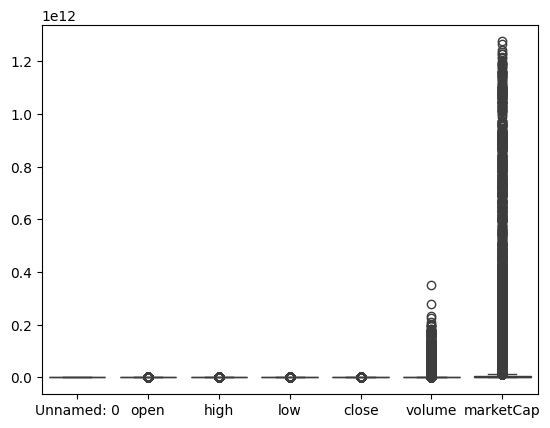

In [29]:
sns.boxplot(data = df)

In [30]:
Q1 = df['marketCap'].quantile(0.25)
Q3 = df['marketCap'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['marketCap'] >= Q1 - 1.5*IQR) & (df['marketCap'] <= Q3 + 1.5*IQR)]

In [31]:
Q1 = df['volume'].quantile(0.25)
Q3 = df['volume'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['volume'] >= Q1 - 1.5*IQR) & (df['volume'] <= Q3 + 1.5*IQR)]

**EDA**

Text(0.5, 1.0, 'Histplot Analysis of Crypto names')

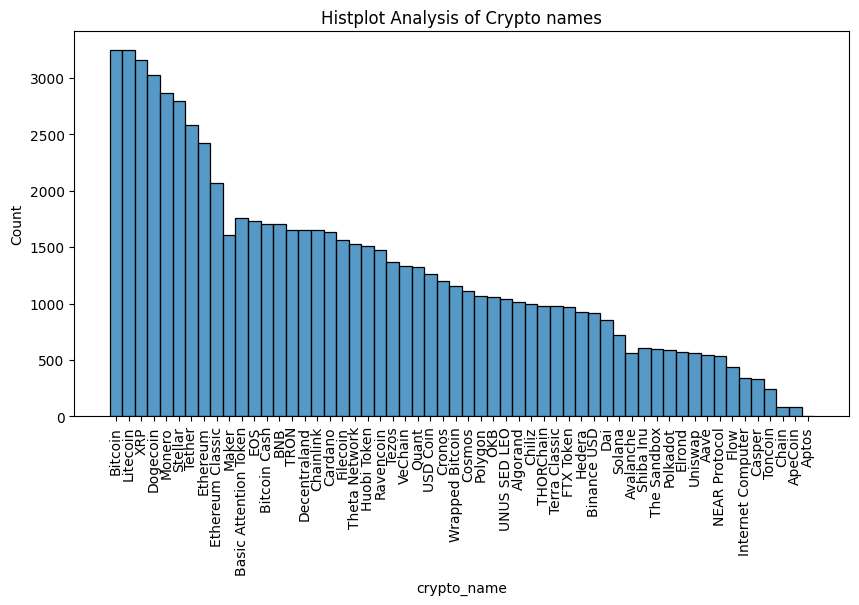

In [32]:
# Histogram
plt.figure(figsize=(10,5))
sns.histplot(x='crypto_name', data=df)
plt.xticks(rotation = 90)
plt.title('Histplot Analysis of Crypto names')

Crypto_name

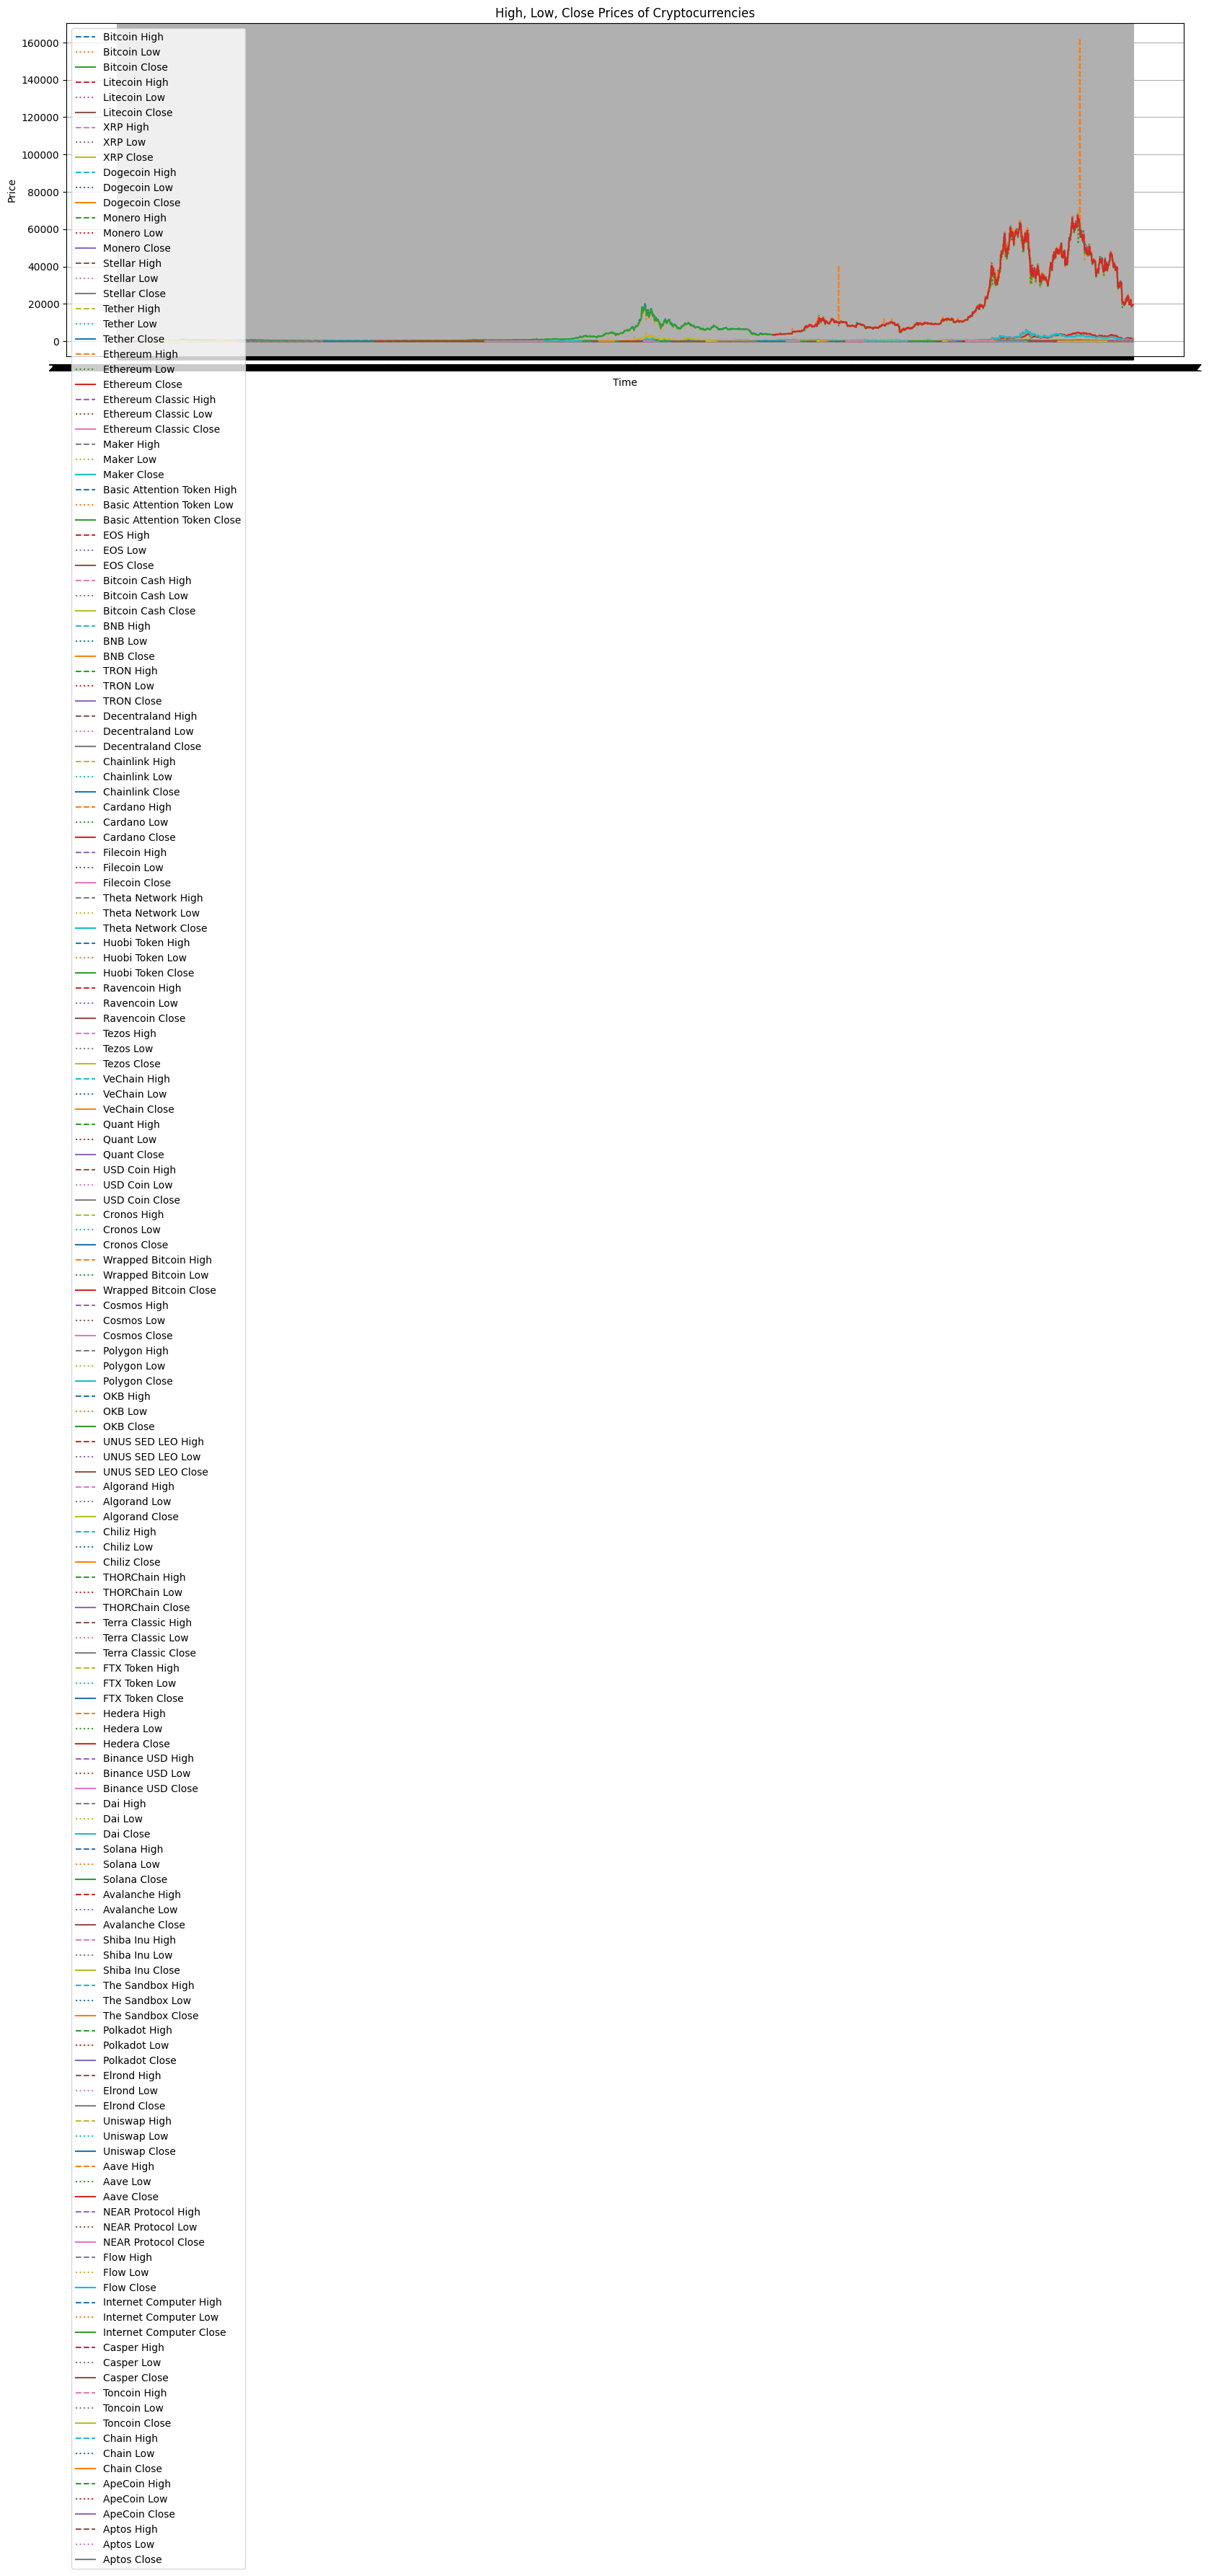

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

for crypto in df['crypto_name'].unique():
    temp = df[df['crypto_name'] == crypto]

    plt.plot(temp['timestamp'], temp['high'], label=f'{crypto} High', linestyle='--')
    plt.plot(temp['timestamp'], temp['low'], label=f'{crypto} Low', linestyle=':')
    plt.plot(temp['timestamp'], temp['close'], label=f'{crypto} Close')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('High, Low, Close Prices of Cryptocurrencies')
plt.legend()
plt.grid(True)
plt.show()


**Implimenting Machine Learning Models**

In [34]:
df['crypto_name'].unique()

array(['Bitcoin', 'Litecoin', 'XRP', 'Dogecoin', 'Monero', 'Stellar',
       'Tether', 'Ethereum', 'Ethereum Classic', 'Maker',
       'Basic Attention Token', 'EOS', 'Bitcoin Cash', 'BNB', 'TRON',
       'Decentraland', 'Chainlink', 'Cardano', 'Filecoin',
       'Theta Network', 'Huobi Token', 'Ravencoin', 'Tezos', 'VeChain',
       'Quant', 'USD Coin', 'Cronos', 'Wrapped Bitcoin', 'Cosmos',
       'Polygon', 'OKB', 'UNUS SED LEO', 'Algorand', 'Chiliz',
       'THORChain', 'Terra Classic', 'FTX Token', 'Hedera', 'Binance USD',
       'Dai', 'Solana', 'Avalanche', 'Shiba Inu', 'The Sandbox',
       'Polkadot', 'Elrond', 'Uniswap', 'Aave', 'NEAR Protocol', 'Flow',
       'Internet Computer', 'Casper', 'Toncoin', 'Chain', 'ApeCoin',
       'Aptos'], dtype=object)

In [35]:
from sklearn.preprocessing import LabelEncoder

cryptos = [
    'Bitcoin', 'Litecoin', 'XRP', 'Dogecoin', 'Monero', 'Stellar',
    'Tether', 'Ethereum', 'Ethereum Classic', 'Maker',
    'Basic Attention Token', 'EOS', 'Bitcoin Cash', 'BNB', 'TRON',
    'Decentraland', 'Chainlink', 'Cardano', 'Filecoin',
    'Theta Network', 'Huobi Token', 'Ravencoin', 'Tezos', 'VeChain',
    'Quant', 'USD Coin', 'Cronos', 'Wrapped Bitcoin', 'Cosmos',
    'Polygon', 'OKB', 'UNUS SED LEO', 'Algorand', 'Chiliz',
    'THORChain', 'Terra Classic', 'FTX Token', 'Hedera', 'Binance USD',
    'Dai', 'Solana', 'Avalanche', 'Shiba Inu', 'The Sandbox',
    'Polkadot', 'Elrond', 'Uniswap', 'Aave', 'NEAR Protocol', 'Flow',
    'Internet Computer', 'Casper', 'Toncoin', 'Chain', 'ApeCoin',
    'Aptos'
]

le = LabelEncoder()
encoded = le.fit_transform(cryptos)

mapping = dict(zip(cryptos, encoded))
print(mapping)

{'Bitcoin': np.int64(8), 'Litecoin': np.int64(30), 'XRP': np.int64(55), 'Dogecoin': np.int64(19), 'Monero': np.int64(32), 'Stellar': np.int64(41), 'Tether': np.int64(45), 'Ethereum': np.int64(22), 'Ethereum Classic': np.int64(23), 'Maker': np.int64(31), 'Basic Attention Token': np.int64(6), 'EOS': np.int64(20), 'Bitcoin Cash': np.int64(9), 'BNB': np.int64(5), 'TRON': np.int64(43), 'Decentraland': np.int64(18), 'Chainlink': np.int64(13), 'Cardano': np.int64(10), 'Filecoin': np.int64(25), 'Theta Network': np.int64(48), 'Huobi Token': np.int64(28), 'Ravencoin': np.int64(38), 'Tezos': np.int64(46), 'VeChain': np.int64(53), 'Quant': np.int64(37), 'USD Coin': np.int64(51), 'Cronos': np.int64(16), 'Wrapped Bitcoin': np.int64(54), 'Cosmos': np.int64(15), 'Polygon': np.int64(36), 'OKB': np.int64(34), 'UNUS SED LEO': np.int64(50), 'Algorand': np.int64(1), 'Chiliz': np.int64(14), 'THORChain': np.int64(42), 'Terra Classic': np.int64(44), 'FTX Token': np.int64(24), 'Hedera': np.int64(27), 'Binance 

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = df.drop(['Unnamed: 0', 'timestamp', 'date', 'crypto_name', 'close'], axis=1)
y = df['close']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


**Linear Regression**

In [39]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f'R-squared score: {r2:.2f}')

R-squared score: 1.00


**Random Forest**

In [43]:
from sklearn.ensemble import RandomForestRegressor
m = RandomForestRegressor( n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
m.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [44]:
pred = m.predict(X_test)
r_score = r2_score(y_test, pred)
print(f'R-squared score: {r_score:.2f}')

R-squared score: 1.00
